In [1]:
from skimage import transform
from matplotlib import pyplot as plt
import numpy as np  
import cv2 as cv

def get_sift_features(img1, img2):
    # Convert to grayscale
    img1_gray = cv.cvtColor(img1, cv.COLOR_RGB2GRAY)
    img2_gray = cv.cvtColor(img2, cv.COLOR_RGB2GRAY)

    # Get SIFT descriptors
    sift = cv.SIFT_create(nOctaveLayers = 3,contrastThreshold = 0.09, edgeThreshold = 25, sigma = 1) 
    keypoints1, descriptors1 = sift.detectAndCompute(img1_gray, None)
    keypoints2, descriptors2 = sift.detectAndCompute(img2_gray, None)

    # Match using Brute Force Matcher
    bf = cv.BFMatcher()
    matches = bf.knnMatch(descriptors1, descriptors2, k=2)

    # Lowe's ratio to filter best matches
    best_matches = []
    for m,n in matches:
        if m.distance < 0.75*n.distance:
            best_matches.append(m)

    return best_matches, keypoints1, keypoints2

(-0.5, 1599.5, 639.5, -0.5)

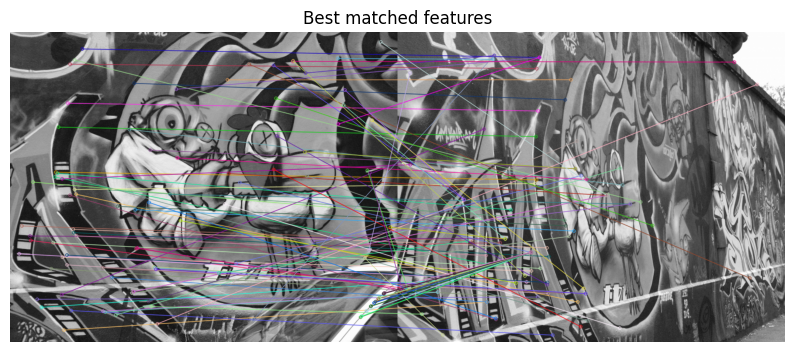

In [2]:
img1 = cv.imread("graf/graf/img1.ppm")
assert img1 is not None
img1 = cv.cvtColor(img1, cv.COLOR_BGR2RGB)

img5 = cv.imread("graf/graf/img5.ppm")
assert img5 is not None
img5 = cv.cvtColor(img5, cv.COLOR_BGR2RGB)

best_matches, keypoints1, keypoints5 = get_sift_features(img1, img5)

plt.figure(figsize=(10, 10))
matched_img = cv.drawMatches(cv.cvtColor(img1, cv.COLOR_BGR2GRAY), keypoints1, cv.cvtColor(img5, cv.COLOR_BGR2GRAY), keypoints5, best_matches, None, flags=cv.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS)
plt.imshow(matched_img)
plt.title("Best matched features")
plt.axis('off')

In [3]:
def get_inliers(src_full, dst_full, tform, thres):
    dst_check = tform(src_full)
    errors = np.sqrt(np.sum(np.square(dst_check - dst_full), axis = 1))

    return np.where(errors < thres)[0]

In [4]:
def find_best_homography(good_matches, keypoints1, keypoints5):
    # Array of all the matching points
    src_full = []
    dst_full = []

    for match in good_matches:
        src_full.append(np.array(keypoints1[match.queryIdx].pt))
        dst_full.append(np.array(keypoints5[match.trainIdx].pt))

    src_full = np.array(src_full)
    dst_full = np.array(dst_full)

    # RANSAC for finding best homography
    num_points = 4
    thres = 1
    d = 0.5 * len(good_matches)
    iters = 2000

    best_homography = None
    best_inlier_count = 0
    best_inliers = None

    for i in range(iters):
        chosen_matches = np.random.choice(good_matches, num_points, replace = False)

        src_points = []
        dst_points = []
        for match in chosen_matches:
            src_points.append(np.array(keypoints1[match.queryIdx].pt))
            dst_points.append(np.array(keypoints5[match.trainIdx].pt))

        src_points = np.array(src_points)
        dst_points = np.array(dst_points)

        tform = transform.estimate_transform('projective', src_points, dst_points)
        inliers = get_inliers(src_full, dst_full, tform, thres)
        #print(f'Iteration {i}: No. of inliers = {len(inliers)}')

        if len(inliers) > best_inlier_count:
            best_inlier_count = len(inliers)
            best_homography = tform
            best_inliers = inliers

    print(f'Best no. of inliers = {best_inlier_count}')
    return best_homography, best_inliers

Best no. of inliers = 23


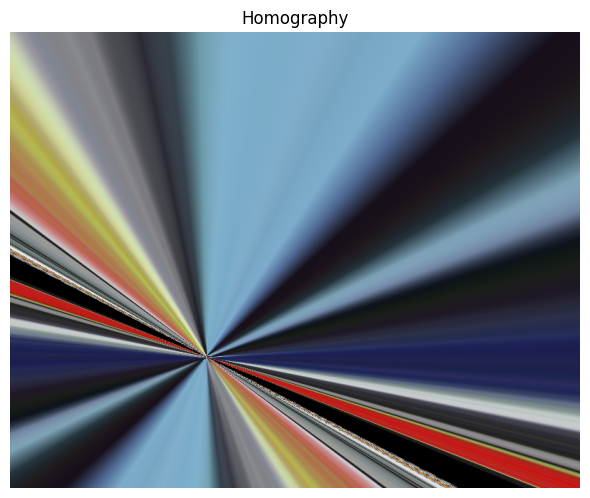

In [5]:
np.random.seed(62)
pad = 100

final_transform = transform.ProjectiveTransform(np.identity(3))
final_transformed_image = transform.warp(img1, final_transform.inverse)

good_matches, keypoints1, keypoints5 = get_sift_features(img1, img5)
tform, _ = find_best_homography(good_matches, keypoints1, keypoints5)

final_transformed_image = transform.warp(final_transformed_image, tform.inverse)
final_transform = final_transform + tform

plt.figure(figsize = (6, 6))
plt.imshow(final_transformed_image)
plt.title(f"Homography")
plt.axis('off')
plt.tight_layout()

Image 1 shape: (640, 800, 3)
Image 5 shape: (640, 800, 3)
Found 109 good matches


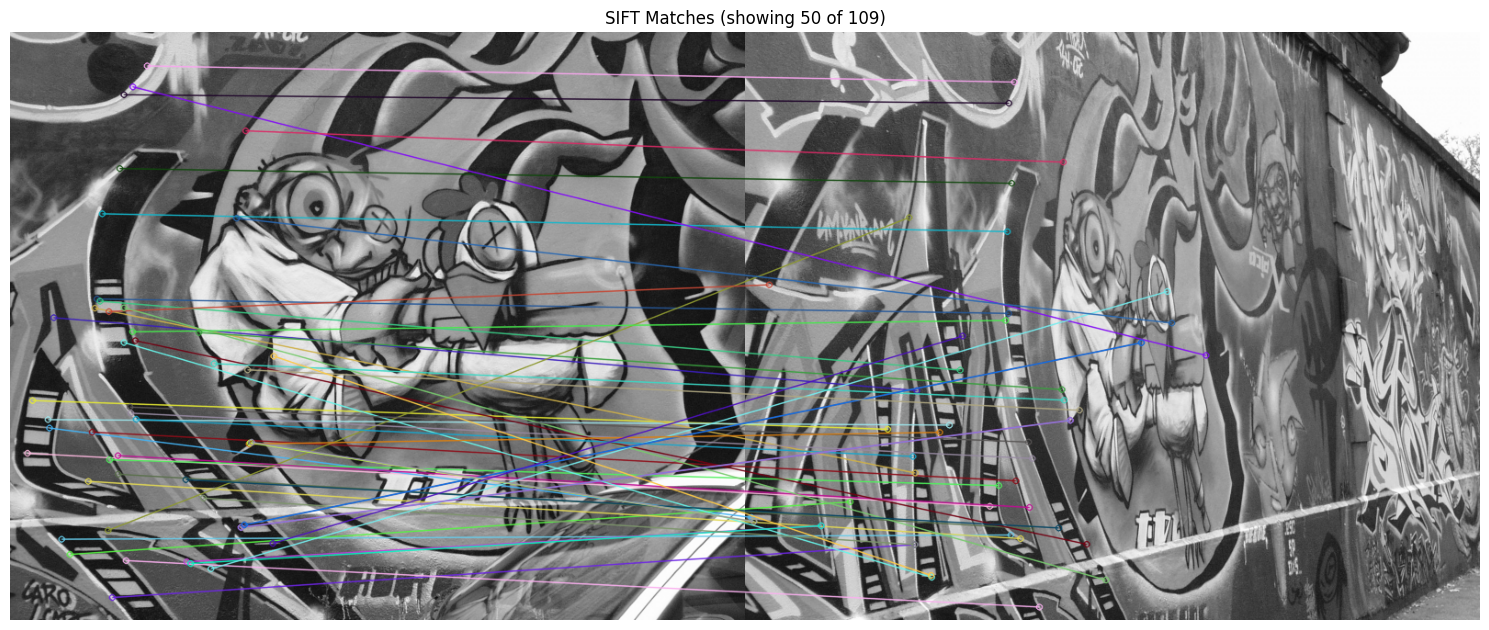

Total matches for RANSAC: 109
Best no. of inliers = 26 / 109
Refitting with 26 inliers
Homography matrix:
[[ 4.14412230e-01 -7.02460849e-01  2.74762098e+02]
 [ 6.88098044e-01 -1.17797569e+00  4.61733309e+02]
 [ 1.50788070e-03 -2.55693995e-03  1.00000000e+00]]


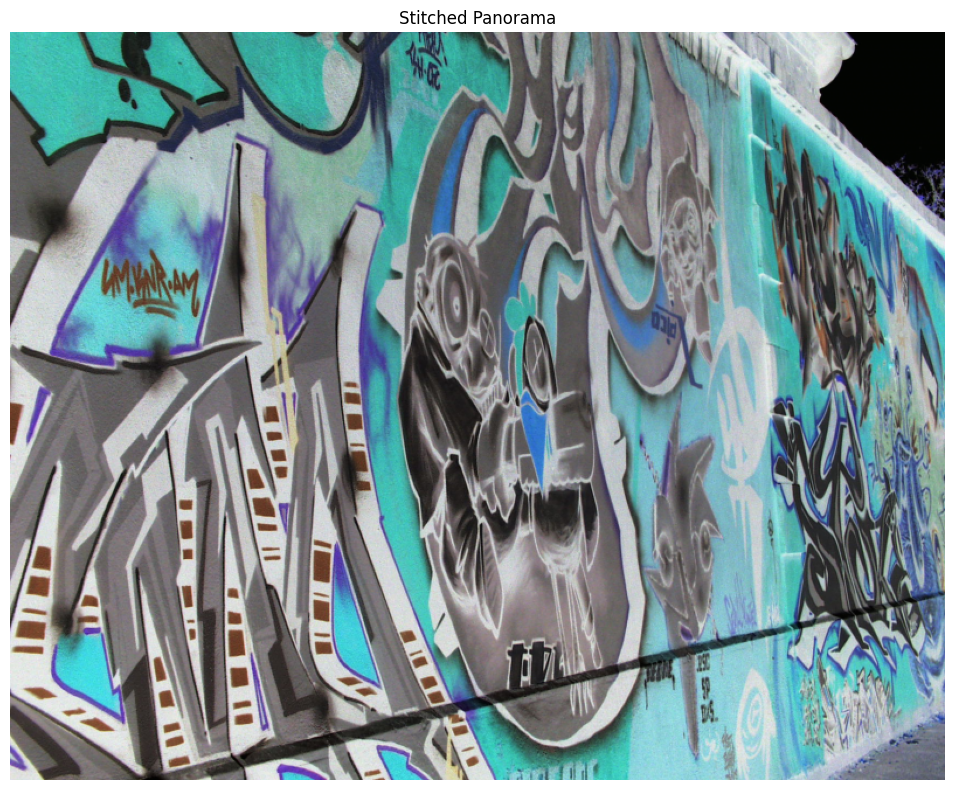

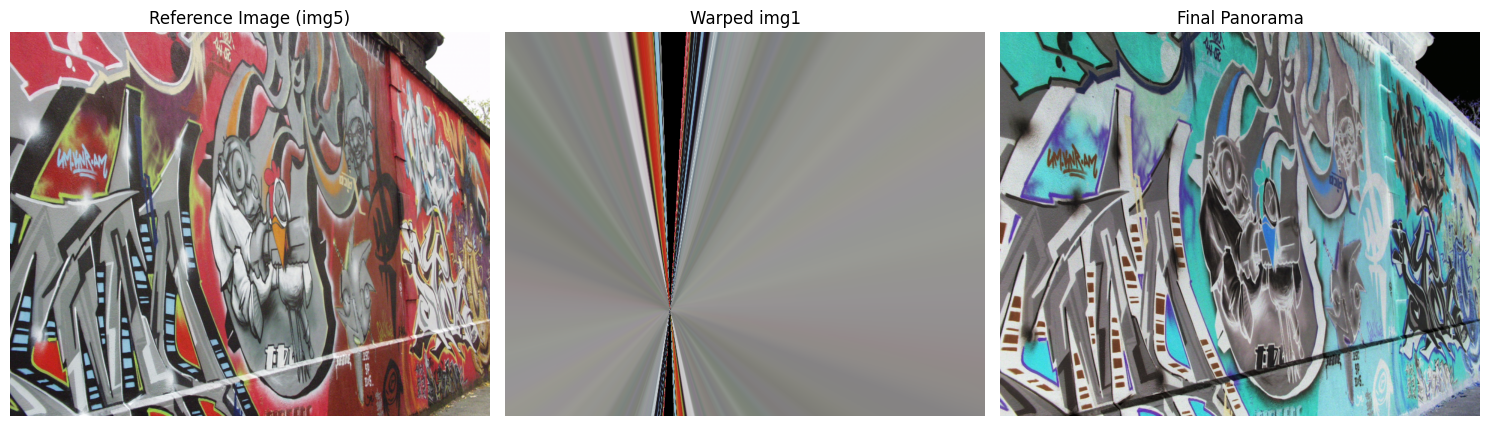


Provided homography matrix:
[[ 6.2544644e-01  5.7759174e-02  2.2201217e+02]
 [ 2.2240536e-01  1.1652147e+00 -2.5605611e+01]
 [ 4.9212545e-04 -3.6542424e-05  1.0000000e+00]]

Difference between computed and provided homography:
[[2.11034210e-01 7.60220023e-01 5.27499282e+01]
 [4.65692684e-01 2.34319039e+00 4.87338920e+02]
 [1.01575525e-03 2.52039752e-03 0.00000000e+00]]


In [7]:
from skimage import transform
from matplotlib import pyplot as plt
import numpy as np  
import cv2 as cv

def get_sift_features(img1, img2):
    # Convert to grayscale
    img1_gray = cv.cvtColor(img1, cv.COLOR_RGB2GRAY)
    img2_gray = cv.cvtColor(img2, cv.COLOR_RGB2GRAY)

    # Get SIFT descriptors
    sift = cv.SIFT_create(nOctaveLayers=3, contrastThreshold=0.09, edgeThreshold=25, sigma=1) 
    keypoints1, descriptors1 = sift.detectAndCompute(img1_gray, None)
    keypoints2, descriptors2 = sift.detectAndCompute(img2_gray, None)

    # Match using Brute Force Matcher
    bf = cv.BFMatcher()
    matches = bf.knnMatch(descriptors1, descriptors2, k=2)

    # Lowe's ratio to filter best matches
    best_matches = []
    for m,n in matches:
        if m.distance < 0.75*n.distance:
            best_matches.append(m)

    print(f"Found {len(best_matches)} good matches")
    return best_matches, keypoints1, keypoints2

def get_inliers(src_full, dst_full, tform, thres):
    # Transform source points to destination space
    src_homo = np.column_stack([src_full, np.ones(len(src_full))])
    dst_pred_homo = tform.params @ src_homo.T
    # Avoid division by zero by adding small epsilon
    dst_pred_homo[2] = np.where(dst_pred_homo[2] == 0, 1e-10, dst_pred_homo[2])
    dst_pred = (dst_pred_homo[:2] / dst_pred_homo[2]).T
    
    errors = np.sqrt(np.sum(np.square(dst_pred - dst_full), axis=1))
    return np.where(errors < thres)[0]

def find_best_homography(good_matches, keypoints1, keypoints5):
    # Array of all the matching points
    src_full = []
    dst_full = []

    for match in good_matches:
        src_full.append(np.array(keypoints1[match.queryIdx].pt))
        dst_full.append(np.array(keypoints5[match.trainIdx].pt))

    src_full = np.array(src_full)
    dst_full = np.array(dst_full)

    print(f"Total matches for RANSAC: {len(src_full)}")
    
    # RANSAC for finding best homography
    num_points = 4
    thres = 5.0  # Increased threshold
    iters = 2000

    best_homography = None
    best_inlier_count = 0
    best_inliers = None

    for i in range(iters):
        if len(src_full) < num_points:
            break
            
        chosen_indices = np.random.choice(len(src_full), num_points, replace=False)
        
        src_points = src_full[chosen_indices]
        dst_points = dst_full[chosen_indices]

        try:
            tform = transform.estimate_transform('projective', src_points, dst_points)
            inliers = get_inliers(src_full, dst_full, tform, thres)
            
            if len(inliers) > best_inlier_count:
                best_inlier_count = len(inliers)
                best_homography = tform
                best_inliers = inliers
                
                # Early termination if we have enough inliers
                if len(inliers) > 0.7 * len(src_full):
                    break
        except Exception as e:
            continue

    print(f'Best no. of inliers = {best_inlier_count} / {len(src_full)}')
    
    # Refit with all inliers for better accuracy
    if best_inliers is not None and len(best_inliers) >= 4:
        print(f"Refitting with {len(best_inliers)} inliers")
        best_homography = transform.estimate_transform('projective', 
                                                      src_full[best_inliers], 
                                                      dst_full[best_inliers])
    
    return best_homography, best_inliers

def create_panorama(img1, img5, H):
    """Create a proper panorama by warping img1 to img5's coordinate system"""
    h1, w1 = img1.shape[:2]
    h5, w5 = img5.shape[:2]
    
    # Get corners of img1
    corners_img1 = np.array([[0, 0], [w1, 0], [w1, h1], [0, h1]], dtype=np.float32)
    
    # Transform corners to img5's coordinate system
    corners_homo = np.column_stack([corners_img1, np.ones(4)])
    corners_transformed = (H.params @ corners_homo.T).T
    # Avoid division by zero
    z_coords = corners_transformed[:, 2].copy()
    z_coords[z_coords == 0] = 1e-10
    corners_transformed = corners_transformed[:, :2] / z_coords[:, np.newaxis]
    
    # Calculate output size
    all_corners = np.vstack([corners_transformed, [[0, 0], [w5, 0], [w5, h5], [0, h5]]])
    x_min, y_min = all_corners.min(axis=0).astype(int)
    x_max, y_max = all_corners.max(axis=0).astype(int)
    
    # Create translation matrix to handle negative coordinates
    translation = np.array([
        [1, 0, -x_min],
        [0, 1, -y_min], 
        [0, 0, 1]
    ])
    
    # Combined transformation
    H_combined = transform.ProjectiveTransform(translation @ H.params)
    
    # Warp img1
    output_shape = (y_max - y_min, x_max - x_min, 3)
    img1_warped = transform.warp(img1, H_combined.inverse, output_shape=output_shape)
    
    # Create panorama and place img5
    panorama = img1_warped.copy()
    start_y, start_x = -y_min, -x_min
    end_y, end_x = start_y + h5, start_x + w5
    
    # Ensure we don't go out of bounds
    end_y = min(end_y, panorama.shape[0])
    end_x = min(end_x, panorama.shape[1])
    
    # Simple blending: img5 takes priority in its region
    panorama[start_y:end_y, start_x:end_x] = img5
    
    # Convert to uint8 for proper display
    panorama_uint8 = (panorama * 255).astype(np.uint8)
    
    return panorama_uint8

# Load and process images
img1 = cv.imread("graf/graf/img1.ppm")
assert img1 is not None
img1 = cv.cvtColor(img1, cv.COLOR_BGR2RGB)

img5 = cv.imread("graf/graf/img5.ppm")
assert img5 is not None
img5 = cv.cvtColor(img5, cv.COLOR_BGR2RGB)

print(f"Image 1 shape: {img1.shape}")
print(f"Image 5 shape: {img5.shape}")

# Get SIFT features and matches
best_matches, keypoints1, keypoints5 = get_sift_features(img1, img5)

# Visualize matches (show only first 50 to avoid clutter)
matches_to_show = best_matches[:50] if len(best_matches) > 50 else best_matches
plt.figure(figsize=(15, 8))
matched_img = cv.drawMatches(cv.cvtColor(img1, cv.COLOR_RGB2GRAY), keypoints1, 
                           cv.cvtColor(img5, cv.COLOR_RGB2GRAY), keypoints5, 
                           matches_to_show, None, 
                           flags=cv.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS)
plt.imshow(matched_img, cmap='gray')
plt.title(f"SIFT Matches (showing {len(matches_to_show)} of {len(best_matches)})")
plt.axis('off')
plt.tight_layout()
plt.show()

# Find homography
if len(best_matches) >= 4:
    np.random.seed(62)
    tform, inliers = find_best_homography(best_matches, keypoints1, keypoints5)
    
    if tform is not None:
        print("Homography matrix:")
        print(tform.params)
        
        # Create and display panorama
        panorama = create_panorama(img1, img5, tform)
        
        plt.figure(figsize=(12, 8))
        plt.imshow(panorama)
        plt.title("Stitched Panorama")
        plt.axis('off')
        plt.tight_layout()
        plt.show()
        
        # Also show individual warped image for comparison
        h5, w5 = img5.shape[:2]
        img1_warped_only = transform.warp(img1, tform.inverse, output_shape=(h5, w5))
        img1_warped_uint8 = (img1_warped_only * 255).astype(np.uint8)
        
        plt.figure(figsize=(15, 5))
        
        plt.subplot(1, 3, 1)
        plt.imshow(img5)
        plt.title("Reference Image (img5)")
        plt.axis('off')
        
        plt.subplot(1, 3, 2)
        plt.imshow(img1_warped_uint8)
        plt.title("Warped img1")
        plt.axis('off')
        
        plt.subplot(1, 3, 3)
        plt.imshow(panorama)
        plt.title("Final Panorama")
        plt.axis('off')
        
        plt.tight_layout()
        plt.show()
    else:
        print("Failed to compute homography")
else:
    print(f"Not enough matches for homography estimation. Need at least 4, got {len(best_matches)}")

# Compare with provided homography if available
try:
    H_provided = np.loadtxt('graf/graf/H1to5p')
    print("\nProvided homography matrix:")
    print(H_provided)
    
    if tform is not None:
        print("\nDifference between computed and provided homography:")
        print(np.abs(tform.params - H_provided))
except:
    print("\nCould not load provided homography file")